In [6]:
import sys
import os
# liset_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '../liset_tk'))
curr_path=os.getcwd()
project_dir=os.path.join(curr_path, os.pardir, os.pardir)
print("Project dir:",project_dir)
sys.path.insert(0, project_dir)

# from liset_tk.liset_aux import ripples_std, middle
from liset_tk.signal_aid import bandpass_filter,highpass_filter

from extract_Nripples.utils_encoding import *
import matplotlib.pyplot as plt
# from liset_tk import liset_tk
from liset_tk.liset_paper import liset_paper as liset_tk

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from liset_tk.signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns
from utils import *

Project dir: c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\extract_Nripples\train_pedro\..\..


In [7]:
parent=r"D:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
print("Available datasets:")
for i, dataset in enumerate(datasets):
    print(f"{i}: {dataset}")
print()
dataset=int(input("Dataset to process: "))
# dataset=3
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")

Available datasets:
0: Amigo2_2019-07-11_11-57-07
1: Dlx1_2021-02-12_12-46-54
2: Som2_2019-07-24_12-01-49
3: Thy7-2020-11-11_16-05-00

Processing dataset: Thy7-2020-11-11_16-05-00


In [10]:
scaling_factor=1
bandpass=(100,250)
adapt_threshold=True
time_max=20
data_dir=os.path.join("dataset_up_down",f"{int(scaling_factor*10)}",datasets[dataset]) if not adapt_threshold else os.path.join("dataset_up_down",f"adapt_{time_max}",f"{int(scaling_factor*10)}",datasets[dataset])
reconstructed_signal_path=os.path.join(data_dir, "reconstructed_signal.npy")
up_down_path=os.path.join(data_dir, "up_down.npy")


In [11]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)
ripples=liset.ripples_GT
up_down=np.load(up_down_path)
reconstructed_signal=np.load(reconstructed_signal_path)

In [12]:
channel=1
downsample_factor=30
liset_data=liset.data[:,channel]
channel_filtered=bandpass_filter(liset_data, bandpass=bandpass, fs=liset.fs)
downsampled_liset=decimation_downsampling(channel_filtered,downsample_factor)
ripples_ds=ripples//downsample_factor

In [13]:
def plot_reconstruction(window,up_down, reconstructed_signal, original_signal, ripples, channel,
                         downsample_factor, spikes=False,highpass=False,subwindow=None,both=False,label=True):
    """
    Plots the original and reconstructed signals along with ripples and spikes.
    
    Parameters:
    - window: tuple of (start, end) in seconds for the time window to plot
    - up_down: array containing UP/DOWN spike information
    - reconstructed_signal: array of the reconstructed signal
    - original_signal: array of the original signal
    - ripples: array of ripple events
    - channel: channel index to plot
    - downsample_factor: factor by which the signal was downsampled
    - spikes: boolean indicating whether to plot spikes
    """

    fs_ds = liset.fs // downsample_factor
    start_window, end_window = (np.array(window) * fs_ds).astype(int)

 
    filtered_signal = highpass_filter(reconstructed_signal[:,channel], fs=fs_ds, highpass=highpass)
    
    up_down_window=up_down[start_window:end_window,channel,:]
    reconstructed_window = reconstructed_signal[start_window:end_window, channel]
    filtered_window= filtered_signal[start_window:end_window]
    original_window = original_signal[start_window:end_window]

    absolute_start_idx =start_window
    absolute_end_idx = end_window
    time = np.linspace(window[0], window[1], reconstructed_window.shape[0])

    # If subwindow is defined (e.g., subwindow=(2, 3)), slice data accordingly
    if subwindow:
        sub_start_sec = subwindow[0]
        sub_end_sec = subwindow[1]

        # Convert relative times to indices
        total_points = reconstructed_window.shape[0]
        sub_start_idx = int(sub_start_sec * fs_ds)
        sub_end_idx = int(sub_end_sec * fs_ds )

        # Apply slicing
        reconstructed_window = reconstructed_window[sub_start_idx:sub_end_idx]
        filtered_window = filtered_signal[sub_start_idx:sub_end_idx]
        original_window = original_window[sub_start_idx:sub_end_idx]
        up_down_window = up_down_window[sub_start_idx:sub_end_idx]
        time = time[sub_start_idx:sub_end_idx]
            # Update start/end sample indices relative to full data
        absolute_start_idx += sub_start_idx
        absolute_end_idx = absolute_start_idx + (sub_end_idx - sub_start_idx)
        
     # Ripple masking
    mask = (ripples[:, 1] >= absolute_start_idx) & (ripples[:, 0] <= absolute_end_idx)
    ripples_window = ripples[mask]

    # Spike masking
    up_mask = up_down_window[:, 0] > 0
    down_mask = up_down_window[:, 1] > 0
    up_spike_times = time[up_mask]
    down_spike_times = time[down_mask]

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 5))
    if both:
        min_val = np.min([original_window.min(), reconstructed_window.min(),filtered_window.min()]) * 1.2
        max_val = np.max([original_window.max(), reconstructed_window.max(),filtered_window.max()]) * 1.2
    else:
        min_val = np.min([original_window.min(),filtered_window.min()]) * 1.2
        max_val = np.max([original_window.max(),filtered_window.max()]) * 1.2


    ax.plot(time, original_window, color='black', linewidth=1.5)
    ax.plot(time, filtered_window,linestyle="--", color='green', alpha=0.7)
    if both:
        ax.plot(time, reconstructed_window, linestyle="--", alpha=0.7, color='purple')

    for idx, ripple in enumerate(ripples_window):
        ripple_start = (ripple[0]) / fs_ds
        ripple_end = (ripple[1]) / fs_ds
        print(ripple[0],ripple[1])
        ax.axvspan(ripple_start, ripple_end, color='gold', alpha=0.3,)

    if spikes:
        spike_height = (max_val - min_val) * 0.12
        ax.vlines(up_spike_times, ymin=max_val - spike_height * 2, ymax=max_val - spike_height, color='red', linewidth=1,alpha=0.5, label='UP Spikes')
        ax.vlines(down_spike_times, ymin=min_val + spike_height, ymax=min_val + spike_height * 2, color='blue', linewidth=1, alpha=0.5, label='DN Spikes')

    # Labels and title
    ax.set_xlabel("Time [s]",fontsize=12)
    ax.set_ylabel("Amplitude",fontsize=12)

    ax.set_xlim(min(time),max(time))
    ax.set_ylim(min_val, max_val)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=12)
    title = "Original vs Reconstructed Signal"
    # if highpass:
    #     title += f" (HP {highpass} Hz)"
  
    # if label:
    #     ax.set_title(title, fontsize=13)
    #     # Custom legend
    #     legend_elements = [
    #         Line2D([0], [0], color='black', lw=2, label='Original Signal'),
    #         Line2D([0], [0], color='purple', lw=2, linestyle="--", label='Reconstructed Signal (Unfiltered)') if both else None,
    #         Line2D([0], [0], color='green', lw=2, linestyle="--", label='Reconstructed Signal (HP - 100 Hz)'),
    #         Line2D([0], [0], color='gold', lw=6, alpha=0.3, label='GT Ripples'),
    #     ]
    #     if spikes:
    #         legend_elements += [
    #             Line2D([0], [0], color='red', lw=2, label='UP Spikes'),
    #             Line2D([0], [0], color='blue', lw=2, label='DN Spikes'),
    #         ]

    #     fig.legend(handles=legend_elements, loc='upper center', ncol=len(legend_elements),fontsize=12, bbox_to_anchor=(0.5, 0.00))
    # else:
    #     ax.legend(loc="best")
    # fig.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return fig, ax

160 201
301 333
431 493
775 829
2837 2875
2877 2923
3017 3080
3239 3289
3553 3609
4172 4216
4410 4451
4683 4736
4925 4980
5647 5697
5766 5814
5929 5978
6129 6169
6341 6371
6489 6542
6674 6725
7033 7083
7469 7549
7674 7738
7943 7981
8114 8171
8220 8273
15076 15131
15335 15399
15524 15579
15829 15892
15982 16021
16106 16148
16401 16460
16732 16783
17063 17123
17225 17262
17601 17659
17976 18015
18323 18383
18702 18738
18895 18948
19322 19363
19442 19485
19743 19783
20293 20334
20521 20567
20659 20703
20792 20833
20912 20963
25429 25477
25587 25658
25730 25802
26141 26202
26484 26544
28860 28901
29292 29338
29477 29525
29742 29799
29936 29974
30147 30241
44862 44917
46096 46159
46310 46360
46429 46489
46552 46603
46665 46716
47217 47275
47530 47576
48883 48944
49405 49439
49589 49638
50000 50037
50111 50156
50260 50324
50360 50410
50507 50561
50693 50736
50757 50796
50891 50922
50953 50989
51100 51157
51198 51230
53322 53377
53567 53616
53738 53780
53865 53911
54041 54098
54233 54271
5433

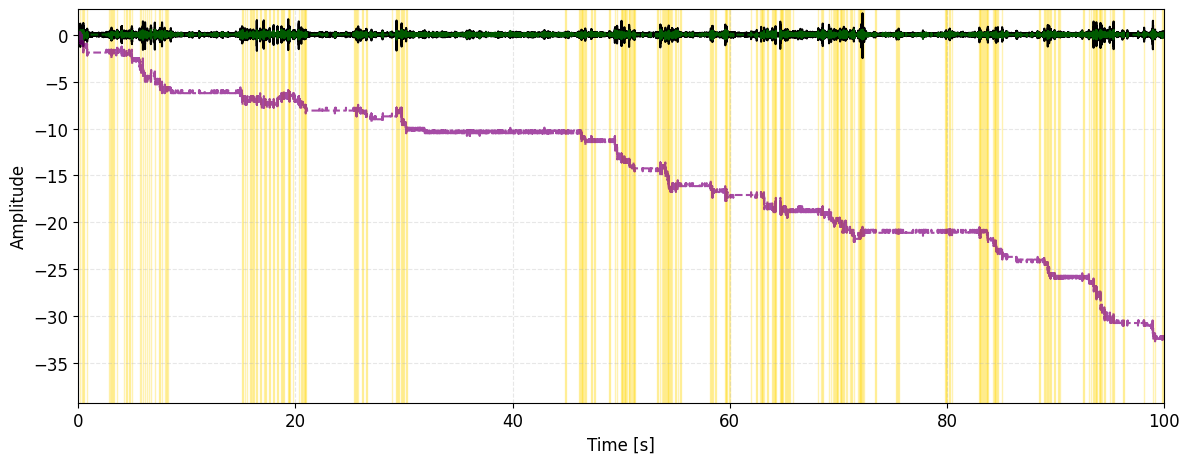

In [14]:
window=np.array([0,100]) # seconds
fig,ax=plot_reconstruction(window,up_down, reconstructed_signal, downsampled_liset, ripples_ds, channel, downsample_factor, spikes=False,highpass=100,both=True)
# Save to file
save_fig = os.path.join(os.getcwd(), "figures")
os.makedirs(save_fig, exist_ok=True)
filename= os.path.join(save_fig, f"reconstruction_plot.png")
# fig.savefig(filename, dpi=300, bbox_inches='tight')

65115 65152
65261 65344
65487 65532
65811 65852
68125 68166
68400 68441
68532 68565
69105 69146
69301 69362
69463 69517
69570 69646
69732 69828
69886 69938


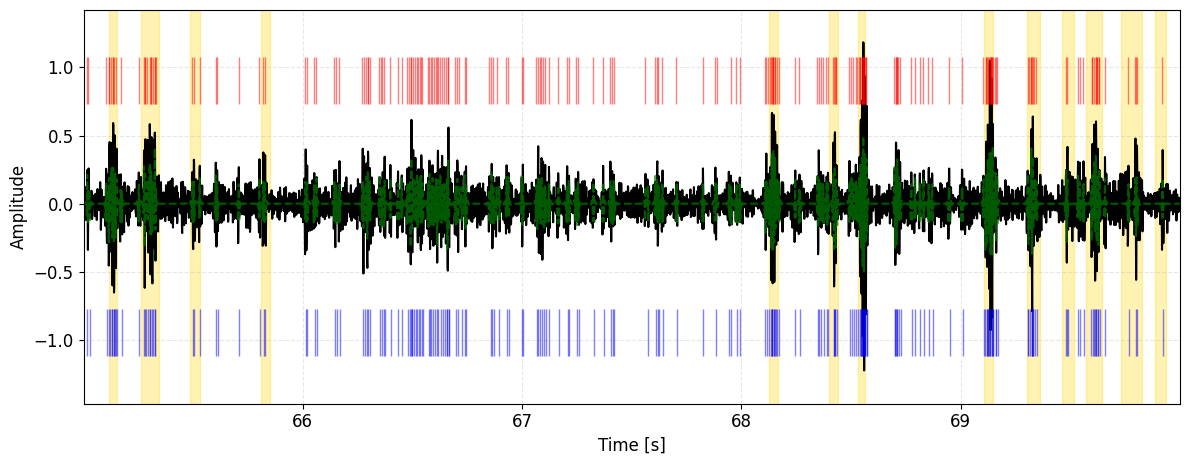

In [15]:
subwindow=(65,70)
# subwindow=(53,54)
fig,ax=plot_reconstruction(window,up_down, reconstructed_signal, downsampled_liset, ripples_ds, channel, downsample_factor,subwindow=subwindow, spikes=True,highpass=100,both=False,label=False)
# filename= os.path.join(save_fig, f"reconstruction_plot_zoomed.png")
# fig.savefig(filename, dpi=300, bbox_inches='tight')

In [16]:
def plot_reconstruction_flags(window, up_down, reconstructed_signal, original_signal, ripples, channel,
                         downsample_factor, spikes=False, highpass=False, subwindow=None, 
                         plot_original=True, plot_filtered=True, plot_reconstructed=False, 
                         plot_ripples=True, plot_spikes=False, label=True, original_signal_high_res=None):
    """
    Plots original / reconstructed / filtered signals, with optional ripples and spikes.

    Parameters
    ----------
    window : tuple
        (start, end) in seconds for the time window to plot.
    up_down : ndarray
        Array containing UP/DOWN spike information.
    reconstructed_signal : ndarray
        Reconstructed signal [samples x channels].
    original_signal : ndarray
        Original signal [samples x channels].
    ripples : ndarray
        Array of ripple events (start_idx, end_idx).
    channel : int
        Channel index to plot.
    downsample_factor : int
        Factor by which the signal was downsampled.
    spikes : bool
        Whether to plot spikes (overrides plot_spikes).
    highpass : float or bool
        Highpass cutoff for filtering, or False for no filter.
    subwindow : tuple
        (start, end) in seconds relative to `window` for zoomed view.
    plot_original, plot_filtered, plot_reconstructed, plot_ripples, plot_spikes : bool
        Toggles for each element.
    label : bool
        Whether to add legend labels.
    original_signal_high_res : ndarray, optional
        Original signal in high resolution [samples]. If provided, this will be plotted instead of original_signal (downsampled).
    """

    fs_ds = liset.fs // downsample_factor
    start_window, end_window = (np.array(window) * fs_ds).astype(int)

    filtered_signal = highpass_filter(reconstructed_signal[:, channel], fs=fs_ds, highpass=highpass)

    up_down_window = up_down[start_window:end_window, channel, :]
    reconstructed_window = reconstructed_signal[start_window:end_window, channel]
    filtered_window = filtered_signal[start_window:end_window]
    original_window = original_signal[start_window:end_window]

    absolute_start_idx = start_window
    absolute_end_idx = end_window
    time = np.linspace(window[0], window[1], reconstructed_window.shape[0])

    # Handle high res original signal
    if original_signal_high_res is not None:
        fs_high = liset.fs
        start_window_high, end_window_high = (np.array(window) * fs_high).astype(int)
        original_window_high = original_signal_high_res[start_window_high:end_window_high]
        time_high = np.linspace(window[0], window[1], original_window_high.shape[0])

    # Subwindow handling
    if subwindow:
        sub_start_sec, sub_end_sec = subwindow
        sub_start_idx = int(sub_start_sec * fs_ds)
        sub_end_idx = int(sub_end_sec * fs_ds)

        reconstructed_window = reconstructed_window[sub_start_idx:sub_end_idx]
        filtered_window = filtered_signal[sub_start_idx:sub_end_idx]
        original_window = original_window[sub_start_idx:sub_end_idx]
        up_down_window = up_down_window[sub_start_idx:sub_end_idx]
        time = time[sub_start_idx:sub_end_idx]

        absolute_start_idx += sub_start_idx
        absolute_end_idx = absolute_start_idx + (sub_end_idx - sub_start_idx)

        if original_signal_high_res is not None:
            sub_start_idx_high = int(sub_start_sec * fs_high)
            sub_end_idx_high = int(sub_end_sec * fs_high)
            original_window_high = original_window_high[sub_start_idx_high:sub_end_idx_high]
            time_high = time_high[sub_start_idx_high:sub_end_idx_high]

    # Ripple masking
    mask = (ripples[:, 1] >= absolute_start_idx) & (ripples[:, 0] <= absolute_end_idx)
    ripples_window = ripples[mask]

    # Spike masking
    up_mask = up_down_window[:, 0] > 0
    down_mask = up_down_window[:, 1] > 0
    up_spike_times = time[up_mask]
    down_spike_times = time[down_mask]

    # Plotting
    fig, ax = plt.subplots(figsize=(9, 3))

    # Axis range
    y_vals = []
    if plot_original: 
        if original_signal_high_res is not None:
            y_vals.append(original_window_high)
        else:
            y_vals.append(original_window)
    if plot_filtered: 
        y_vals.append(filtered_window)
    if plot_reconstructed: 
        y_vals.append(reconstructed_window)
    if not plot_original and not plot_filtered and not plot_reconstructed and spikes:
        y_vals.extend([-1, 1])
        min_val=-1
        max_val=1
    else:
        min_val = min([arr.min() for arr in y_vals]) * 1.2
        max_val = max([arr.max() for arr in y_vals]) * 1.2
    min_val=-2
    max_val=2

    if plot_original:
        if original_signal_high_res is not None:
            ax.plot(time_high, original_window_high, color='black', linewidth=1.5, label="Original Signal")
        else:
            ax.plot(time, original_window, color='black', linewidth=1.5, label="Original Signal")
    if plot_filtered:
        ax.plot(time, filtered_window, linestyle="--", color='green', alpha=0.7,
                label=f"Filtered (HP {highpass} Hz)" if highpass else "Filtered")
    if plot_reconstructed:
        ax.plot(time, reconstructed_window, linestyle="--", alpha=0.7, color='purple', label="Reconstructed")

    if plot_ripples and len(ripples_window) > 0:
        for ripple in ripples_window:
            ripple_start, ripple_end = ripple / fs_ds
            ax.axvspan(ripple_start, ripple_end, color='gold', alpha=0.3, label="Ripple")

    if plot_spikes or spikes:
        spike_height = (max_val - min_val) * 0.12
        ax.vlines(up_spike_times, ymin=max_val - spike_height*2, ymax=max_val - spike_height,
                  color='red', linewidth=1, alpha=0.5, label='UP Spikes')
        ax.vlines(down_spike_times, ymin=min_val + spike_height, ymax=min_val + spike_height*2,
                  color='blue', linewidth=1, alpha=0.5, label='DN Spikes')

    # Labels & formatting
    # ax.set_xlabel("Time [s]", fontsize=12)
    # ax.set_ylabel("Amplitude", fontsize=14)
    ax.set_xlim(min(time), max(time))
    ax.set_ylim(min_val, max_val)
    # ax.grid(False, linestyle='--', alpha=0.3)
    ax.grid(False)
    ax.tick_params(axis='both', which='major',labelsize=14,width=1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.3)
    ax.spines['left'].set_linewidth(1.3)
    
    # Set ticks in ms relative to start
    start_t = time[0]
    end_t = time[-1]
    ticks = np.arange(start_t + 0.1, end_t + 0.001, 0.1)
    # ax.set_xticks(ticks)
    # ax.set_xticklabels([f"{int(round((t - start_t) * 1000))}" for t in ticks], fontsize=14)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", which='major', bottom=False, top=False)
    ax.set_ylim(-2,2)
    if label:
        ax.legend(loc="upper right", fontsize=10)

    plt.tight_layout()
    return fig, ax

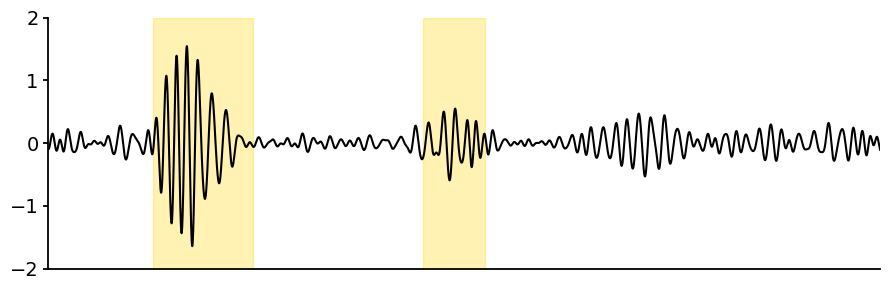

In [17]:
# subwindow=(16.97,17.47)
subwindow=(17,17.5)
original_signal_high_res=channel_filtered

fig,ax=plot_reconstruction_flags(window,up_down, reconstructed_signal, downsampled_liset, ripples_ds, channel, downsample_factor,subwindow=subwindow, spikes=False,highpass=100, 
                                 plot_original=True, plot_filtered=False, plot_reconstructed=False, plot_ripples=True, plot_spikes=False,label=False,original_signal_high_res=original_signal_high_res)
# Save to file
filename= os.path.join(save_fig, f"after_encoder_spikes4.svg")
# fig.savefig(filename, dpi=300, bbox_inches='tight')

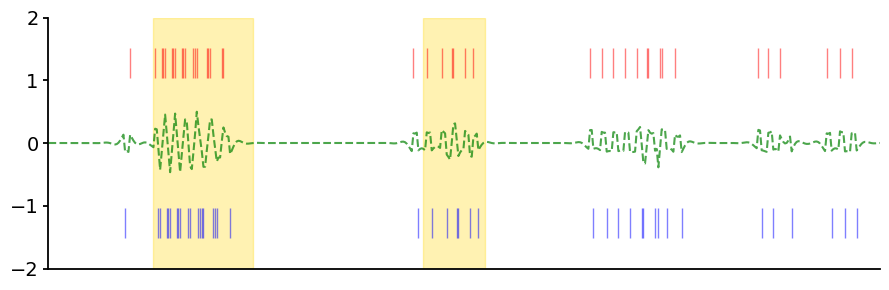

In [18]:
fig,ax=plot_reconstruction_flags(window,up_down, reconstructed_signal, downsampled_liset, ripples_ds, channel, downsample_factor,subwindow=subwindow, spikes=True,highpass=100, 
                                 plot_original=False, plot_filtered=True, plot_reconstructed=True, plot_ripples=True, plot_spikes=False,label=False,original_signal_high_res=original_signal_high_res)
# Save to file
filename= os.path.join(save_fig, f"after_encoder_all.svg")
# fig.savefig(filename, dpi=300, bbox_inches='tight')

In [1]:
from scipy import signal
# Plot the spectrogram of the original signal over the same subwindow
fs_og = liset.fs
start_window, end_window = (np.array(window) * fs_og).astype(int)
sub_start_sec, sub_end_sec = subwindow
sub_start_idx = int(sub_start_sec * fs_og)
sub_end_idx = int(sub_end_sec * fs_og)
signal_segment = liset_data[start_window + sub_start_idx : start_window + sub_end_idx]

# Compute spectrogram (power) and convert to dB
f, t_spec, Sxx = signal.spectrogram(signal_segment, fs=fs_og, nperseg=256, noverlap=128)
Sxx_db = 10 * np.log10(Sxx + 1e-12)
# Shift spectrogram times to match the subwindow absolute seconds
t_spec = t_spec + sub_start_sec

fig, ax = plt.subplots(figsize=(9, 4))
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=Sxx_db.min(), vmax=Sxx_db.max())
im = ax.pcolormesh(t_spec, f, Sxx_db, shading='gouraud', cmap=cmap, norm=norm)
cb = fig.colorbar(im, ax=ax)
cb.set_label('Power (dB)', fontsize=12)

ax.set_xlabel("Time [s]", fontsize=12)
ax.set_ylim(0, 500)
ax.set_ylabel("Frequency [Hz]", fontsize=12)
ax.set_title("Spectrogram", fontsize=13)

# Add colored scalebars using a color sampled from the spectrogram colormap
median_power = np.median(Sxx_db)
bar_color = cmap(norm(median_power))
# Horizontal time bar (50 ms) placed at 85% from start
duration = (sub_end_sec - sub_start_sec)
x0 = sub_start_sec + duration * 0.85
y0 = 50
bar_duration = 0.05  # 50 ms
ax.plot([x0, x0 + bar_duration], [y0, y0], color="black", linewidth=3)
ax.text(x0 + bar_duration/2, y0 - 30, '50 ms', ha='center', fontsize=10, color="black")
# Vertical frequency bar (50 Hz)
ax.plot([x0 - 0.01, x0 - 0.01], [y0, y0 + 50], color="black", linewidth=3)
ax.text(x0 - 0.03, y0 + 25, '50 Hz', va='center', fontsize=10, color="black", rotation=90)

plt.tight_layout()
plt.show()

NameError: name 'liset' is not defined

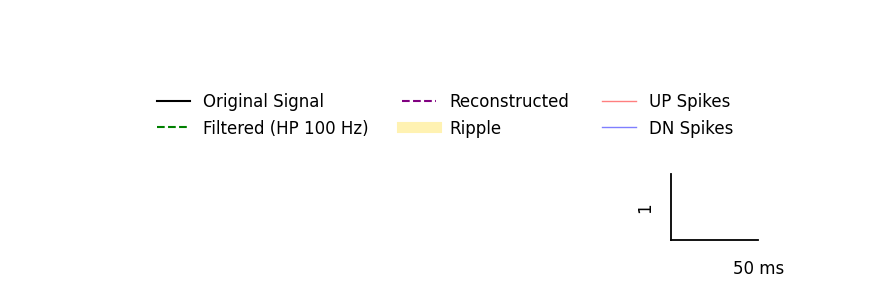

In [95]:
def plot_legend_scale_only(save_path=None):
    # Create figure with same dimensions as data plots
    fig, ax = plt.subplots(figsize=(9, 3))
    
    # Set limits to match the zoomed plot (0.5s window, -2 to 2 amplitude)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(-2, 2)
    
    # Hide axes
    ax.axis('off')
    
    # Legend elements
    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, label='Original Signal'),
        Line2D([0], [0], color='green', lw=1.5, linestyle="--", label='Filtered (HP 100 Hz)'),
        Line2D([0], [0], color='purple', lw=1.5, linestyle="--", label='Reconstructed'),
        Line2D([0], [0], color='gold', lw=8, alpha=0.3, label='Ripple'),
        Line2D([0], [0], color='red', lw=1, alpha=0.5, label='UP Spikes'),
        Line2D([0], [0], color='blue', lw=1, alpha=0.5, label='DN Spikes'),
    ]
    
    # Add legend
    ax.legend(handles=legend_elements, loc='center', fontsize=12, frameon=False, ncol=3, bbox_to_anchor=(0.5, 0.6))
    
    # Scale bars
    # Place in bottom right
    x0 = 0.38
    y0 = -1.5
    
    # Vertical bar (1 unit)
    ax.plot([x0, x0], [y0, y0 + 1], color='black', linewidth=1.3)
    ax.text(x0 - 0.01, y0 + 0.5, "1", rotation=90, va='center', ha='right', fontsize=12)
    
    # Horizontal bar (100 ms = 0.1 s)
    ax.plot([x0, x0 + 0.05], [y0, y0], color='black', linewidth=1.3)
    ax.text(x0 + 0.05, y0 - 0.3, "50 ms", va='top', ha='center', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Save to file
filename = os.path.join(save_fig, "legend_and_scale.svg")
plot_legend_scale_only(filename)